# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import warnings, json, time, matplotlib, torch
warnings.filterwarnings("ignore")
matplotlib.use("Agg")
from pathlib import Path
root_dir = Path().resolve()

from unsloth.trainer import UnslothVisionDataCollator
from unsloth import FastVisionModel

import numpy as np
import pandas as pd
from trl import SFTTrainer, SFTConfig
import random
random.seed(42)
from common_utils import run_model, train_dataset_file, test_dataset_file, configure_eager_generation
from train_utils import create_data_new, filter_dataset_by_length

load = True
use_finetuned = False

CUDA_DEVICE_COUNT = torch.cuda.device_count()
device_ids = list(range(CUDA_DEVICE_COUNT))
primary_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = primary_device

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", CUDA_DEVICE_COUNT)
if CUDA_DEVICE_COUNT:
    for gpu_id in range(CUDA_DEVICE_COUNT):
        print(f"GPU {gpu_id}:", torch.cuda.get_device_name(gpu_id))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch: 2.10.0+cu128
CUDA runtime: 12.8
CUDA available: True
CUDA device count: 2
GPU 0: NVIDIA RTX A4000
GPU 1: NVIDIA RTX A4000


## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [2]:
max_seq_length = 2048

In [3]:
model_name = {
	1: "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
	2: "unsloth/gemma-3-4b-pt",
    3: "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit"
}
choice = 3

In [4]:
model, processor = FastVisionModel.from_pretrained(
	model_name[choice],
	load_in_4bit=True,
	use_gradient_checkpointing="unsloth",
	device_map="auto",
)
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True, 
    finetune_attention_modules=True,
    finetune_mlp_modules=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    random_state=3407,
    use_rslora=True,
    loftq_config=None,
)

==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX A4000. Num GPUs = 2. Max memory: 15.724 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 675.51it/s]
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


## Step 9: Prepare Train/Test Split

Create disjoint train and test datasets for fine-tuning and evaluation.

**Improvements for better performance:**
- ✨ Increased training set to **100 examples** (was 50)
- ✨ Increased test set to **30 examples** (was 20)
- ✨ Relaxed code length filter to **1000 chars** (was 800)

In [5]:
# Load all data

train_samples = [json.loads(l) for l in open(train_dataset_file)]
test_samples = [json.loads(l) for l in open(test_dataset_file)]

print(f"Total training examples: {len(train_samples)}")
print(f"Total test examples: {len(test_samples)}")

Total training examples: 1870
Total test examples: 82


In [6]:
train_dataset = create_data_new(train_samples)

Converting to conversation:   0%|          | 0/1870 [00:00<?, ?it/s]

Converting to conversation: 100%|██████████| 1870/1870 [00:20<00:00, 93.18it/s] 


In [7]:
for i in train_dataset:
    if i.get("vega_spec"):
        print(i)
        break

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=362x359 at 0x7F8C16D8FE00>}, {'type': 'text', 'text': 'You are an expert data visualization engineer.\nReturn ONLY a valid Vega-Lite JSON specification that recreates the given plot.\n\nSTRICT REQUIREMENTS:\n1. Return a single JSON object, not Python code and not markdown.\n2. Include inline data in data.values whenever the values are visually inferable.\n3. Use ONLY this supported plot subset: line, scatter, bar, histogram, heatmap, boxplot, area, multi-line, grouped bar.\n4. Use Vega-Lite mark, encoding, scale, axis, title, transform, and layer fields as needed.\n5. Match the visible plot type, colors, markers, labels, scales, legends, annotations, and layout.\n6. Do NOT add extra styling, grids, titles, legends, annotations, or subplots that are not visible.\n7. Prefer simple Vega-Lite v5/v6-compatible JSON.\n\nReturn ONLY raw JSON with no markdown or explanation.'}]}, {'role':

In [8]:
counter = 0
for i in train_dataset:
    if not i.get("vega_spec"):
        print(i)
        break
    counter += 1

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=378x351 at 0x7F8DBA9831A0>}, {'type': 'text', 'text': 'You are an expert Python data visualization engineer.\nReturn ONLY executable Python code that recreates the given plot.\n\nSTRICT REQUIREMENTS:\n1. Use matplotlib.pyplot as plt and numpy as np when needed.\n2. Define all data explicitly with no placeholders.\n3. Match the visible plot type, colors, markers, labels, scales, legends, annotations, and layout.\n4. Do NOT add extra styling, grids, titles, legends, annotations, or subplots that are not visible.\n5. Code MUST run without errors.\n6. End with plt.show().\n\nReturn ONLY raw Python code with no markdown or explanation.'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '\nimport matplotlib.pyplot as plt\nimport numpy as np\n\nplt.style.use(\'_mpl-gallery-nogrid\')\n\nx = np.linspace(-4, 4, 6)\ny = np.linspace(-4, 4, 6)\nX, Y = np.meshgrid(x, y)\nU = X + Y\

In [9]:
counter

3

In [10]:
test_dataset = create_data_new(test_samples)

Converting to conversation:   0%|          | 0/82 [00:00<?, ?it/s]

Converting to conversation: 100%|██████████| 82/82 [00:00<00:00, 436.47it/s]


## Step 9.6: Baseline - Zero-Shot Evaluation on Test Set

Evaluate the zero-shot model on the test set to establish a baseline before fine-tuning.

In [11]:
def prepare_model_for_inference():
    """Move the model into inference mode before benchmark generation."""
    configure_eager_generation()
    FastVisionModel.for_inference(model)
    model.eval()

In [12]:
from datetime import datetime
date_str = datetime.now().strftime("%d_%m")

In [13]:
if not load:
	folder = f"{date_str}/zero_shot_{model_name[choice].split('/')[-1]}"
	prepare_model_for_inference()
	zeroshot_results, zeroshot_df, zeroshot_successful = run_model(model, processor, test_samples, desc=folder)
else:
	load_date = date_str
	load_folder = f"{load_date}/zero_shot_{model_name[choice].split('/')[-1]}"
	with open(f"{load_folder}/results.json", "r") as f:
		zeroshot_results = json.load(f)
	zeroshot_df = pd.read_csv(f"{load_folder}/res_df.csv")
	zeroshot_successful = pd.read_csv(f"{load_folder}/res_successful.csv")

In [14]:
model_path = f"./{date_str}/plot2code_lora_final"
dtype = torch.float16

In [15]:
# Apply filtering to training dataset
print("Filtering training dataset to prevent token mismatches...")
train_dataset_filtered = filter_dataset_by_length(
    train_dataset,
    max_code_length=2000,
    processor=processor,
    max_total_tokens=max_seq_length,
)
print(f"Training dataset ready: {len(train_dataset_filtered)} samples")

Filtering training dataset to prevent token mismatches...


Filtering dataset: 100%|██████████| 1870/1870 [03:43<00:00,  8.38it/s]


✓ Filtered dataset: Removed 673 samples outside the length limits
  Original: 1870 → Filtered: 1197 samples
  Dropped by legacy code length: 64
  Dropped by processor token length: 609
Training dataset ready: 1197 samples
Training dataset ready: 1197 samples


In [16]:
train_dataset_filtered[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=362x359>},
    {'type': 'text',
     'text': 'You are an expert Python data visualization engineer.\nReturn ONLY executable Python code that recreates the given plot.\n\nSTRICT REQUIREMENTS:\n1. Use matplotlib.pyplot as plt and numpy as np when needed.\n2. Define all data explicitly with no placeholders.\n3. Match the visible plot type, colors, markers, labels, scales, legends, annotations, and layout.\n4. Do NOT add extra styling, grids, titles, legends, annotations, or subplots that are not visible.\n5. Code MUST run without errors.\n6. End with plt.show().\n\nReturn ONLY raw Python code with no markdown or explanation.'}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': "\nimport matplotlib.pyplot as plt\nimport numpy as np\n\nplt.style.use('_mpl-gallery-nogrid')\n\nnp.random.seed(1)\nx = np.random.uniform(-3, 3, 256)\ny = np.random.uniform(-3, 3, 

In [17]:
if use_finetuned:
    fine_tuned_model_path = f"./{load_date}/plot2code_lora_final"
    try:
        print("Loading Saved model!!")
        model, processor = FastVisionModel.from_pretrained(
            model_name=fine_tuned_model_path,
            max_seq_length=max_seq_length,
            dtype=dtype,
            load_in_4bit=True,
        )
        print("Model Loaded Successfully")
    except Exception as e:
        print(f"Model Loading Failed due to {e}")
else:
    print("Finetuning Fresh model!!")
    FastVisionModel.for_training(model)  # Enable for training!
    model.train()  # Set model to training mode

    # checkpoint_path = f"./{date_str}/plot2code_lora_final/checkpoint-300"

    trainer = SFTTrainer(
        model=model,
        processing_class=processor,
        data_collator=UnslothVisionDataCollator(model, processor),
        train_dataset=train_dataset_filtered,  # Use filtered dataset
        eval_dataset=test_dataset,
        args=SFTConfig(
            per_device_train_batch_size=2,
            per_device_eval_batch_size=1,
            gradient_accumulation_steps=4,
            warmup_ratio=0.04,
            num_train_epochs=6,
            learning_rate=5e-6,
            logging_steps=25,
            max_grad_norm=0.5,
            lr_scheduler_type="cosine",
            seed=3407,
            output_dir=model_path,
            report_to="none",
            remove_unused_columns=False,
            bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
            fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
            eval_strategy="steps",
            eval_steps=50,
            dataset_text_field="",
            save_total_limit=2,
            dataset_kwargs={"skip_prepare_dataset": True},
            max_length=max_seq_length,
            torch_compile=False,
            save_strategy="steps",
            save_steps=100,
            optim="paged_adamw_32bit",
            weight_decay=0.01,
            metric_for_best_model="eval_loss",
            load_best_model_at_end=True,
            greater_is_better=False,
        ),
    )

    # Start fine-tuning
    print("Starting fine-tuning...")
    print("=" * 80)

    # trainer.train(resume_from_checkpoint=checkpoint_path)
    trainer.train()

    print("=" * 80)
    print("Fine-tuning complete!")

    # Save the final LoRA adapter
    model.save_pretrained(model_path)
    print(f"LoRA adapter saved to {model_path}")

Finetuning Fresh model!!
Unsloth: Model does not have a default image size - using 512


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 1,197 | Num Epochs = 6 | Total steps = 900
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 8,781,824 of 2,136,313,856 (0.41% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,1.602585,1.455646
100,1.168904,0.956553
150,0.685013,0.611779
200,0.599442,0.544163
250,0.525119,0.526092
300,0.506029,0.519351
350,0.538398,0.508091
400,0.458674,0.495764
450,0.436524,0.493088
500,0.454159,0.494950


Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-700/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_05/plot2code_lora_final/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./25_

Fine-tuning complete!
LoRA adapter saved to ./25_05/plot2code_lora_final


In [18]:
if not use_finetuned:
	try:
		# Extract training history from trainer 
		if hasattr(trainer.state, "log_history"):
			logs = trainer.state.log_history

			# Extract loss values
			train_loss = []
			steps = []

			for entry in logs:
				if "loss" in entry:
					train_loss.append(entry["loss"])
					steps.append(entry["step"])

			if len(train_loss) > 0:
				# Create loss plot
				fig, ax = plt.subplots(1, 1, figsize=(12, 6))

				ax.plot(
					steps,
					train_loss,
					marker="o",
					linestyle="-",
					linewidth=2,
					markersize=4,
					color="#2E86AB",
					alpha=0.8,
					label="Training Loss",
				)
				ax.set_xlabel("Training Steps", fontsize=12, fontweight="bold")
				ax.set_ylabel("Loss", fontsize=12, fontweight="bold")
				ax.set_title("Training Loss over Time", fontsize=14, fontweight="bold")
				ax.grid(True, alpha=0.3)

				# Add trend line
				if len(steps) > 1:
					z = np.polyfit(steps, train_loss, 2)
					p = np.poly1d(z)
					ax.plot(
						steps,
						p(steps),
						"--",
						color="red",
						alpha=0.5,
						linewidth=2,
						label="Polynomial Trend",
					)
					ax.legend(fontsize=11)

				plt.tight_layout()
				plt.savefig(f"{date_str}/training_loss_curve.png", dpi=150, bbox_inches="tight")
				print(f"✓ Training loss curve saved to {date_str}/training_loss_curve.png\n")

				# Display the plot inline
				plt.show()

				# Print summary statistics
				print(f"\n{'='*80}")
				print(f"📊 TRAINING LOSS SUMMARY")
				print(f"{'='*80}")
				print(f"  Initial loss:     {train_loss[0]:.4f}")
				print(f"  Final loss:       {train_loss[-1]:.4f}")
				print(
					f"  Loss reduction:   {train_loss[0] - train_loss[-1]:.4f} ({(train_loss[0] - train_loss[-1])/train_loss[0]*100:.1f}%)"
				)
				print(
					f"  Min loss:         {min(train_loss):.4f} (at step {steps[train_loss.index(min(train_loss))]})"
				)
				print(f"  Total steps:      {len(steps)}")
				print(f"{'='*80}\n")

				# Save loss history to CSV
				loss_df = pd.DataFrame({"step": steps, "loss": train_loss})
				loss_df.to_csv(f"{date_str}/training_loss_history_{model_name[choice].split('/')[-1]}.csv", index=False)
				print(f"✓ Loss history saved to {date_str}/training_loss_history_{model_name[choice].split('/')[-1]}.csv")
			else:
				print("⚠️ No loss values found in training logs")
		else:
			print("⚠️ No training history available. Make sure to run training first.")
	except NameError:
		print("⚠️ Trainer not found. Loaded Saved Model.")
else:
	print("Loaded Fine-tuned Model, skipping training loss plot.")

✓ Training loss curve saved to 25_05/training_loss_curve.png


📊 TRAINING LOSS SUMMARY
  Initial loss:     2.0516
  Final loss:       0.4631
  Loss reduction:   1.5886 (77.4%)
  Min loss:         0.3614 (at step 700)
  Total steps:      36

✓ Loss history saved to 25_05/training_loss_history_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit.csv


## Step 12: Quantitative Evaluation on Test Set

Run comprehensive evaluation on the held-out test set and compute aggregate metrics.

In [19]:
test_samples[0:2]

[{'image': '/home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/patheffects_guide.png',
  'code': "\n\nimport matplotlib.pyplot as plt\n\nimport matplotlib.patheffects as path_effects\n\nfig = plt.figure(figsize=(5, 1.5))\ntext = fig.text(0.5, 0.5, 'Hello path effects world!\\nThis is the normal '\n                          'path effect.\\nPretty dull, huh?',\n                ha='center', va='center', size=20)\ntext.set_path_effects([path_effects.Normal()])\nplt.show()\n\nimport matplotlib.patheffects as path_effects\n\ntext = plt.text(0.5, 0.5, 'Hello path effects world!',\n                path_effects=[path_effects.withSimplePatchShadow()])\n\nplt.plot([0, 3, 2, 5], linewidth=5, color='blue',\n         path_effects=[path_effects.SimpleLineShadow(),\n                       path_effects.Normal()])\nplt.show()\n\nfig = plt.figure(figsize=(7, 1))\ntext = fig.text(0.5, 0.5, 'This text stands out because of\\n'\n                          'its black border.', color='white',\n         

Evaluating fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit model on test set...


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):   0%|          | 0/14 [00:00<?, ?it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/patheffects_guide.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/boxplot_plot.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/stairs.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/hist2d.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/tricontourf.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/stackplot.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):   7%|▋         | 1/14 [02:25<31:26, 145.09s/it]

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/hexbin.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/contourf.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/ecdf.png
No figure created for image: ecdf.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/contour.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/scatter_plot.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/scatter_plot.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (7): ['DataFrame', 'scatter', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'scatter', 'set_xlabel', 'set_ylabel', 'show

### Evaluation Summary: `scatter_plot.png`

**Visual:** SSIM `0.516`
**Code:** BLEU `0.207` · Edit `0.223` · API `1.000`
**API Details:** Matched `{'set_ylabel', 'scatter', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'show'}` · Missed `set()` · Extra `set()`
**Aggregate:** CodeScore `0.450` · Overall `0.483`

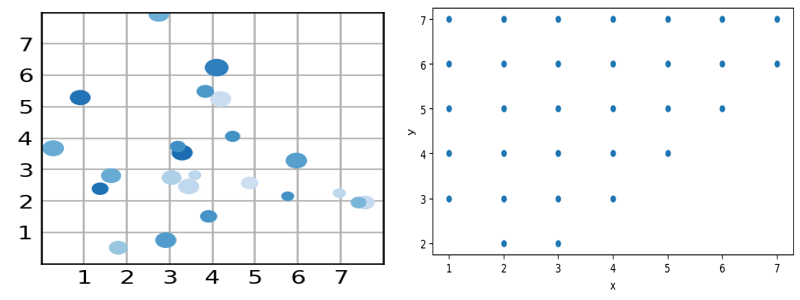

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/violin.png
✓ Memory cleaned


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  14%|█▍        | 2/14 [04:51<29:09, 145.76s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/ellipse_arrow.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/hatch_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/pyplot_three.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/pyplot_simple.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/integral.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/fivethirtyeight.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/fivethirtyeight.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (10): ['DataFrame', 'groupby', 'legend', 'plot', 'set_title', 'set_xlabel', 'set

### Evaluation Summary: `fivethirtyeight.png`

**Visual:** SSIM `0.561`
**Code:** BLEU `0.000` · Edit `0.016` · API `0.700`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend', 'set_title'}` · Extra `set()`
**Aggregate:** CodeScore `0.215` · Overall `0.388`

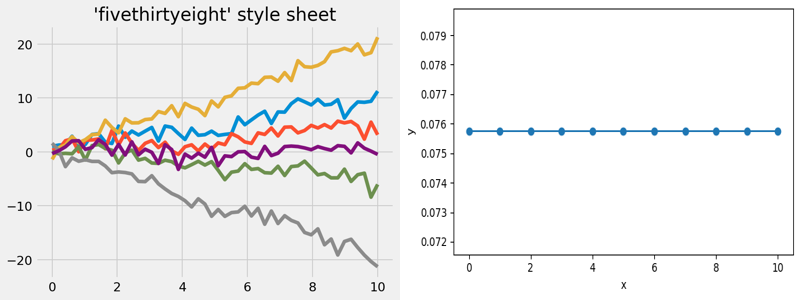

✓ Memory cleaned


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  21%|██▏       | 3/14 [07:19<26:55, 146.88s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/polar_bar.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/bmh.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/polar_legend.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/contours_in_optimization_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/plot_solarizedlight2.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/plot_solarizedlight2.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (10): ['DataFrame', 'groupby', 'legend', 'plot', 'set_title', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'plot'

### Evaluation Summary: `plot_solarizedlight2.png`

**Visual:** SSIM `0.628`
**Code:** BLEU `0.000` · Edit `0.006` · API `0.700`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend', 'set_title'}` · Extra `set()`
**Aggregate:** CodeScore `0.212` · Overall `0.420`

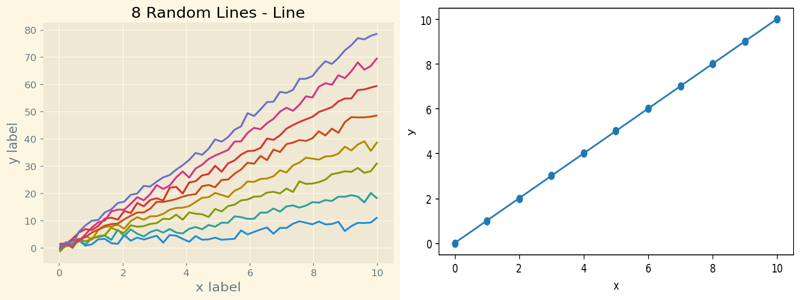

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/grayscale.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  29%|██▊       | 4/14 [09:46<24:29, 147.00s/it]

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/polar_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/ggplot.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/matshow.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/aspect_loglog.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/layer_images.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/text_alignment.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/text_alignment.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (8): ['Rectangle', 'add_patch', 'set_axis_off', 'set_clip_on', 'set_transform', 'show', 's

### Evaluation Summary: `text_alignment.png`

**Visual:** SSIM `0.714`
**Code:** BLEU `0.007` · Edit `0.042` · API `0.250`
**API Details:** Matched `{'show', 'subplots'}` · Missed `{'set_transform', 'text', 'set_clip_on', 'Rectangle', 'add_patch', 'set_axis_off'}` · Extra `{'set_ylabel', 'sin', 'seed', 'arange', 'cos', 'set_xlabel', 'legend', 'plot', 'set_title'}`
**Aggregate:** CodeScore `0.090` · Overall `0.402`

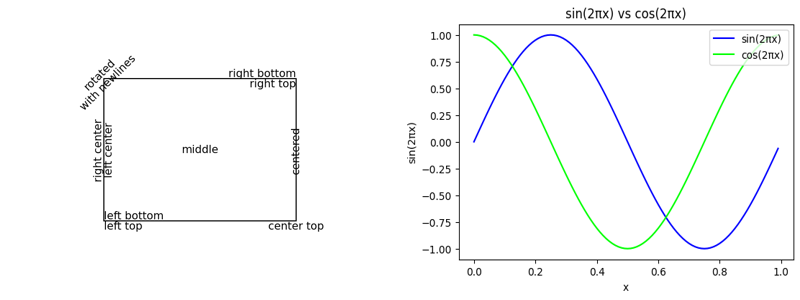

./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  36%|███▌      | 5/14 [12:13<22:02, 146.97s/it]

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/contour_image.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/specgram_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/autowrap.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/placing_text_boxes.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/mri_with_eeg.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/triinterp_demo.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  43%|████▎     | 6/14 [14:40<19:36, 147.02s/it]

...

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/tick_label_right.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/tick_label_right.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (9): ['DataFrame', 'groupby', 'legend', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Matched:  ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Missed:   ['groupby', 'legend']
Extra:    []

Quantitative Scores
--------------------------------------------------------------------------------
SSIM (Visual):       0.657
BLEU (Text):         0.116
Edit Similarity:     0.467
API Overlap:         0.778
Composite CodeScore: 0.420
Ove

### Evaluation Summary: `tick_label_right.png`

**Visual:** SSIM `0.657`
**Code:** BLEU `0.116` · Edit `0.467` · API `0.778`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend'}` · Extra `set()`
**Aggregate:** CodeScore `0.420` · Overall `0.539`

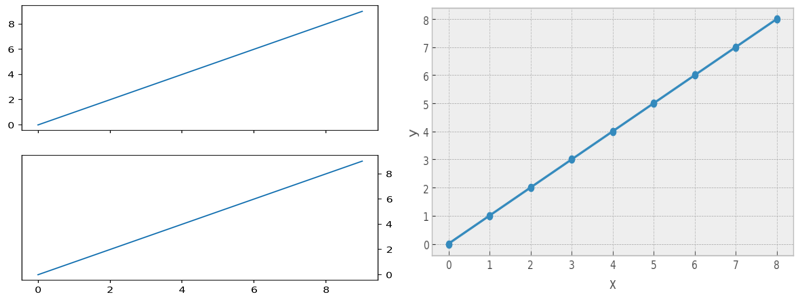

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/centered_ticklabels.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/date_demo_rrule.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/tick_xlabel_top.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/custom_ticker1.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  57%|█████▋    | 8/14 [19:35<14:43, 147.27s/it]

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/tick_labels_from_values.png
✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/mouse_cursor.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/mouse_cursor.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (8): ['locked', 'mpl_connect', 'set', 'set_cursor', 'show', 'subplots', 'suptitle', 'text']
Generated APIs (6): ['grid', 'set_title', 'show', 'subplots', 'text', 'text', 'text', 'text', 'text', 'text', 'text', 'use', 'use']
Matched:  ['show', 'subplots', 'text']
Missed:   ['locked', 'mpl_connect', 'set', 'set_cursor', 'suptitle']
Extra:    ['grid', 'set_title', 'use']

Quantitative Scores
--------------------------------------------------------------------------------
SSIM (Visual):       0.709
BLEU (Text):         0.127
Edit Similarity:     0.072
API Overlap:         0.375
Composite CodeScore: 0.185

### Evaluation Summary: `mouse_cursor.png`

**Visual:** SSIM `0.709`
**Code:** BLEU `0.127` · Edit `0.072` · API `0.375`
**API Details:** Matched `{'show', 'text', 'subplots'}` · Missed `{'locked', 'mpl_connect', 'set', 'set_cursor', 'suptitle'}` · Extra `{'set_title', 'grid', 'use'}`
**Aggregate:** CodeScore `0.185` · Overall `0.447`

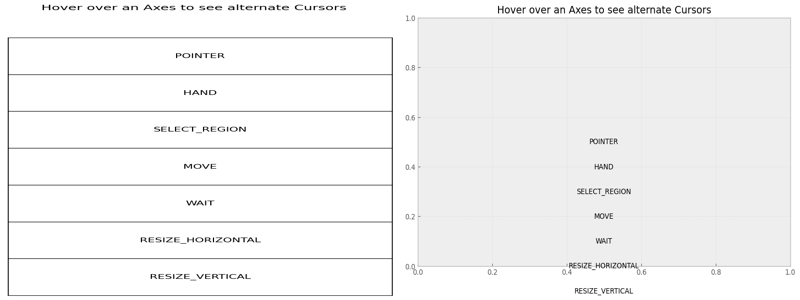

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/simple_plot.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/scatter_demo2.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/line_demo_dash_control.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/simple_axisline.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/radio_buttons.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  64%|██████▍   | 9/14 [22:03<12:15, 147.19s/it]

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/errorbar_limits_simple.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/vline_hline_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/spectrum_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/csd_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/errorbar_features.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/errorbar.png


...

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/boxplot_color.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/histogram_bihistogram.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/table_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/scatter_star_poly.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/set_and_get.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/scalarformatter.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/scalarformatter.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (10): ['DataFrame', 'groupby', 'legend', 'plot', 'set_title', 's

### Evaluation Summary: `scalarformatter.png`

**Visual:** SSIM `0.543`
**Code:** BLEU `0.000` · Edit `0.008` · API `0.700`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend', 'set_title'}` · Extra `set()`
**Aggregate:** CodeScore `0.212` · Overall `0.378`

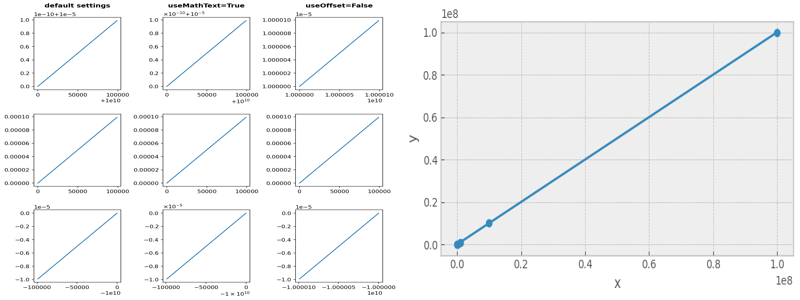

✓ Memory cleaned


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  79%|███████▊  | 11/14 [27:01<07:25, 148.41s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/multipage_pdf.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/print_stdout_sgskip.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/hexbin_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/demo_fixed_size_axes.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/demo_fixed_size_axes.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (9): ['DataFrame', 'groupby', 'legend', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Matched:  ['DataFrame', 'plot', 'set_xlabel', 'set_

### Evaluation Summary: `demo_fixed_size_axes.png`

**Visual:** SSIM `0.665`
**Code:** BLEU `0.289` · Edit `0.453` · API `0.778`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend'}` · Extra `set()`
**Aggregate:** CodeScore `0.485` · Overall `0.575`

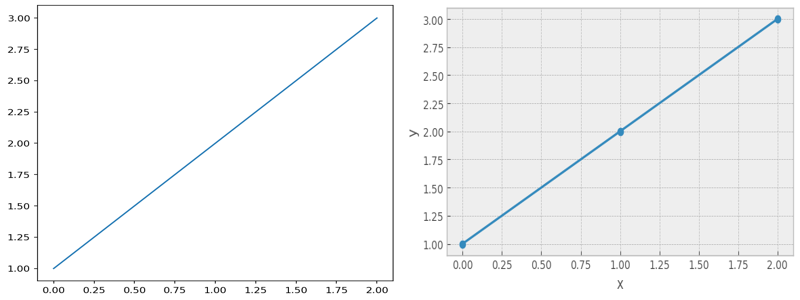

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/scatter_hist_locatable_axes.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/parasite_simple.png


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched):  86%|████████▌ | 12/14 [29:31<04:57, 148.64s/it]

✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/violinplot.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/parasite_simple2.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/centered_spines_with_arrows.png

No plotted content for image: centered_spines_with_arrows.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/colorbar_basics.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/set_alpha.png


...

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/trifinder_event_demo.png
✓ Memory cleaned


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/keypress_demo.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/demo_axes_grid.png
✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/spine_placement_demo.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/spine_placement_demo.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (10): ['DataFrame', 'groupby', 'legend', 'plot', 'set_title', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Matched:  ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Missed:   ['groupby', 'legend', 'set_title']
Extra

### Evaluation Summary: `spine_placement_demo.png`

**Visual:** SSIM `0.682`
**Code:** BLEU `0.001` · Edit `0.017` · API `0.700`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend', 'set_title'}` · Extra `set()`
**Aggregate:** CodeScore `0.215` · Overall `0.449`

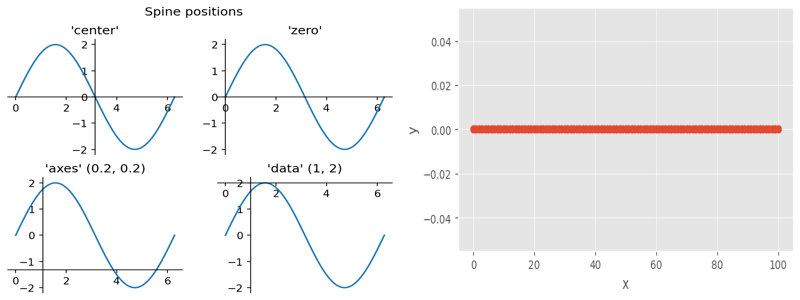

✓ Memory cleaned

Evaluating: /home/em-plot/plot2code/Dhruv/plot2code/plot_gallery_test/spines.png
Image saved at ././25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/spines.png
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (10): ['DataFrame', 'groupby', 'legend', 'plot', 'set_title', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Generated APIs (7): ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Matched:  ['DataFrame', 'plot', 'set_xlabel', 'set_ylabel', 'show', 'subplots', 'tight_layout']
Missed:   ['groupby', 'legend', 'set_title']
Extra:    []

Quantitative Scores
--------------------------------------------------------------------------------
SSIM (Visual):       0.660
BLEU (Text):         0.000
Edit Similarity:     0.015
API Overlap:         0.700
Composite CodeScore: 0.

### Evaluation Summary: `spines.png`

**Visual:** SSIM `0.660`
**Code:** BLEU `0.000` · Edit `0.015` · API `0.700`
**API Details:** Matched `{'set_ylabel', 'subplots', 'tight_layout', 'set_xlabel', 'DataFrame', 'plot', 'show'}` · Missed `{'groupby', 'legend', 'set_title'}` · Extra `set()`
**Aggregate:** CodeScore `0.215` · Overall `0.437`

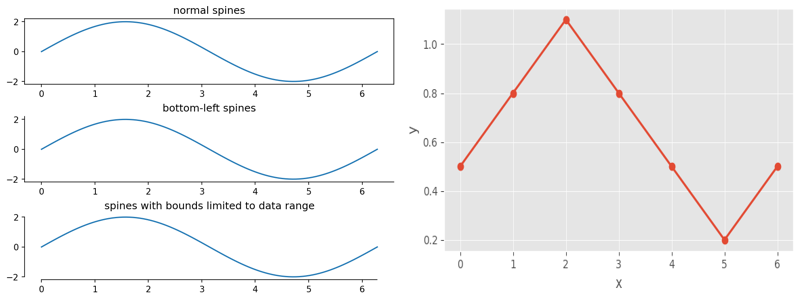

✓ Memory cleaned


./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit (batched): 100%|██████████| 14/14 [34:23<00:00, 147.38s/it]


25_05/FINE_TUNED_QWEN3-VL-2B-INSTRUCT-UNSLOTH-BNB-4BIT MODEL RESULTS ON TEST SET
Total test examples:  82
Successful executions:    10 (12.2%)

Metrics (mean ± std):
  SSIM (Visual):   0.634 ± 0.070
  BLEU (Text):     0.075 ± 0.106
  Edit Similarity: 0.132 ± 0.185
  API Overlap:     0.668 ± 0.211
  Code Score:      0.270 ± 0.132
  Overall Score:   0.452 ± 0.064

25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit results saved to ./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/res_df.csv
Successful results saved to ./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/res_successful.csv
Full results saved to ./25_05/fine_tuned_Qwen3-VL-2B-Instruct-unsloth-bnb-4bit/results.json


In [20]:
folder = f"{date_str}/fine_tuned_{model_name[choice].split('/')[-1]}"
prepare_model_for_inference()
finetuned_results, finetuned_df, finetuned_successful = run_model(model, processor, test_samples, desc=folder)

## Step 12.5: Comparison Table - Zero-Shot vs Fine-Tuned

Direct comparison showing improvement from fine-tuning.

In [21]:
# Create comparison table
print("\n" + "=" * 100)
print("ZERO-SHOT vs FINE-TUNED COMPARISON TABLE")
print("=" * 100)

# Calculate metrics for both models
metrics = ["ssim", "bleu", "edit_sim", "api_sim", "code_score", "overall"]
metric_names = [
	"SSIM (Visual)",
	"BLEU (Text)",
	"Edit Similarity",
	"API Overlap",
	"Code Score",
	"Overall Score",
]

comparison_data = []

for metric, name in zip(metrics, metric_names):
	zs_mean = zeroshot_successful[metric].mean() if len(zeroshot_successful) > 0 else 0
	zs_std = zeroshot_successful[metric].std() if len(zeroshot_successful) > 0 else 0

	ft_mean = (
		finetuned_successful[metric].mean() if len(finetuned_successful) > 0 else 0
	)
	ft_std = finetuned_successful[metric].std() if len(finetuned_successful) > 0 else 0

	# Calculate improvement
	abs_improvement = ft_mean - zs_mean
	rel_improvement = (abs_improvement / zs_mean * 100) if zs_mean > 0 else 0

	comparison_data.append(
		{
			"Metric": name,
			"Zero-Shot": f"{zs_mean:.3f} ± {zs_std:.3f}",
			"Fine-Tuned": f"{ft_mean:.3f} ± {ft_std:.3f}",
			"Absolute Δ": f"{abs_improvement:+.3f}",
			"Relative Δ": f"{rel_improvement:+.1f}%",
		}
	)

# Add execution success rate
zs_success_rate = (
	len(zeroshot_successful) / len(zeroshot_results) * 100
	if len(zeroshot_results) > 0
	else 0
)
ft_success_rate = (
	len(finetuned_successful) / len(finetuned_results) * 100
	if len(finetuned_results) > 0
	else 0
)
success_improvement = ft_success_rate - zs_success_rate

comparison_data.append(
	{
		"Metric": "Execution Success Rate",
		"Zero-Shot": f"{zs_success_rate:.1f}%",
		"Fine-Tuned": f"{ft_success_rate:.1f}%",
		"Absolute Δ": f"{success_improvement:+.1f}%",
		"Relative Δ": f"{(success_improvement/zs_success_rate*100) if zs_success_rate > 0 else 0:+.1f}%",
	}
)

comparison_df = pd.DataFrame(comparison_data)

# Display as formatted table
print("\n")
print(comparison_df.to_string(index=False))
print("\n" + "=" * 100)

# Print summary - FIXED CALCULATION
print("\nKEY FINDINGS:")
print("-" * 100)

# Find best improvements
if len(finetuned_successful) > 0 and len(zeroshot_successful) > 0:
	improvements = []
	for metric, name in zip(metrics, metric_names):
		zs_val = zeroshot_successful[metric].mean()
		ft_val = finetuned_successful[metric].mean()
		abs_imp = ft_val - zs_val
		rel_imp = ((ft_val - zs_val) / zs_val * 100) if zs_val > 0 else 0
		improvements.append((name, rel_imp, abs_imp))

	# Sort by relative improvement
	improvements.sort(key=lambda x: x[1], reverse=True)

	print(f"🏆 Best improvement: {improvements[0][0]}")
	print(
		f"   Relative: {improvements[0][1]:+.1f}%  |  Absolute: {improvements[0][2]:+.3f}"
	)
	print(f"\n🥈 Second best: {improvements[1][0]}")
	print(
		f"   Relative: {improvements[1][1]:+.1f}%  |  Absolute: {improvements[1][2]:+.3f}"
	)

	# Overall score improvement (it's in the list, find it)
	overall_imp = [imp for imp in improvements if imp[0] == "Overall Score"][0]
	zs_overall = zeroshot_successful["overall"].mean()
	ft_overall = finetuned_successful["overall"].mean()

	print(f"\n📊 Overall Score:")
	print(f"   Zero-shot: {zs_overall:.3f}")
	print(f"   Fine-tuned: {ft_overall:.3f}")
	print(
		f"   Improvement: {overall_imp[2]:+.3f} absolute ({overall_imp[1]:+.1f}% relative)"
	)

print("=" * 100)

# Save comparison table
comparison_df.to_csv(f"{date_str}/comparison_zeroshot_vs_finetuned_{model_name[choice].split('/')[-1]}.csv", index=False)
print(f"\n✓ Comparison table saved to {date_str}/comparison_zeroshot_vs_finetuned_{model_name[choice].split('/')[-1]}.csv")


ZERO-SHOT vs FINE-TUNED COMPARISON TABLE


                Metric     Zero-Shot    Fine-Tuned Absolute Δ Relative Δ
         SSIM (Visual) 0.585 ± 0.167 0.634 ± 0.070     +0.048      +8.2%
           BLEU (Text) 0.086 ± 0.067 0.075 ± 0.106     -0.011     -12.9%
       Edit Similarity 0.134 ± 0.111 0.132 ± 0.185     -0.002      -1.8%
           API Overlap 0.458 ± 0.264 0.668 ± 0.211     +0.210     +45.9%
            Code Score 0.212 ± 0.122 0.270 ± 0.132     +0.058     +27.3%
         Overall Score 0.399 ± 0.116 0.452 ± 0.064     +0.053     +13.3%
Execution Success Rate         50.0%         12.2%     -37.8%     -75.6%


KEY FINDINGS:
----------------------------------------------------------------------------------------------------
🏆 Best improvement: API Overlap
   Relative: +45.9%  |  Absolute: +0.210

🥈 Second best: Code Score
   Relative: +27.3%  |  Absolute: +0.058

📊 Overall Score:
   Zero-shot: 0.399
   Fine-tuned: 0.452
   Improvement: +0.053 absolute (+13.3% relative)

✓ Co

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Create side-by-side comparison visualization
if len(zeroshot_successful) > 0 and len(finetuned_successful) > 0:
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

	# --- Left plot: Bar chart comparison ---
	metrics = ["ssim", "bleu", "edit_sim", "api_sim", "code_score", "overall"]
	metric_labels = [
		"SSIM\n(Visual)",
		"BLEU\n(Text)",
		"Edit\nSim",
		"API\nOverlap",
		"Code\nScore",
		"Overall",
	]

	zs_means = [zeroshot_successful[m].mean() for m in metrics]
	ft_means = [finetuned_successful[m].mean() for m in metrics]

	x = np.arange(len(metrics))
	width = 0.35

	bars1 = ax1.bar(
		x - width / 2, zs_means, width, label="Zero-Shot", alpha=0.8, color="coral"
	)
	bars2 = ax1.bar(
		x + width / 2, ft_means, width, label="Fine-Tuned", alpha=0.8, color="skyblue"
	)

	ax1.set_ylabel("Score", fontsize=12, fontweight="bold")
	ax1.set_title(
		"Zero-Shot vs Fine-Tuned Performance Comparison", fontsize=14, fontweight="bold"
	)
	ax1.set_xticks(x)
	ax1.set_xticklabels(metric_labels)
	ax1.legend(fontsize=11)
	ax1.grid(True, alpha=0.3, axis="y")
	ax1.set_ylim([0, 1])

	# Add value labels on bars
	for bars in [bars1, bars2]:
		for bar in bars:
			height = bar.get_height()
			ax1.text(
				bar.get_x() + bar.get_width() / 2.0,
				height,
				f"{height:.3f}",
				ha="center",
				va="bottom",
				fontsize=9,
			)

	# --- Right plot: Improvement percentages ---
	improvements = [
		(ft_means[i] - zs_means[i]) / zs_means[i] * 100 if zs_means[i] > 0 else 0
		for i in range(len(metrics))
	]

	colors = ["green" if imp > 0 else "red" for imp in improvements]
	bars = ax2.barh(metric_labels, improvements, color=colors, alpha=0.7)

	ax2.set_xlabel("Relative Improvement (%)", fontsize=12, fontweight="bold")
	ax2.set_title(
		"Relative Improvement from Fine-Tuning", fontsize=14, fontweight="bold"
	)
	ax2.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
	ax2.grid(True, alpha=0.3, axis="x")

	# Add value labels
	for i, (bar, imp) in enumerate(zip(bars, improvements)):
		ax2.text(imp, i, f" {imp:+.1f}%", va="center", fontsize=10, fontweight="bold")

	plt.tight_layout()
	plt.savefig(f"{date_str}/comparison_zeroshot_vs_finetuned.png", dpi=150, bbox_inches="tight")
	print(f"\n✓ Comparison visualization saved to {date_str}/comparison_zeroshot_vs_finetuned.png")

	# Display inline
	plt.show()

	print("\n📊 Visual comparison displayed above")
else:
	print("⚠️ Not enough successful results to create comparison visualization")


✓ Comparison visualization saved to 25_05/comparison_zeroshot_vs_finetuned.png

📊 Visual comparison displayed above
